<div style="
    background: linear-gradient(135deg, #8B1E3F 0%, #C44569 55%, #F8A5C2 100%);
    padding: 45px 35px;
    border-radius: 20px;
    color: white;
    text-align: center;
    box-shadow: 0 8px 25px rgba(139, 30, 63, 0.25);
">

<div style="font-size: 13px; letter-spacing: 3px; text-transform: uppercase; opacity: 0.9; margin-bottom: 12px;">
    BinX Tech — AI & ML Internship · Week 7 · Day 1
</div>

<h1 style="font-size: 34px; margin: 0; font-weight: 700;">
    Hands-On Lab: Sprint 2 Kickoff & Convolution
</h1>

<p style="font-size: 18px; margin-top: 10px; opacity: 0.92;">
    Cardiac Patient Monitoring System + CNN Foundations
</p>

</div>

## Objective

This lab has two parts:

**Part A — Sprint 2 Kickoff (Cardiac Project)**
I record the Sprint 2 plan and initialize the experiment log with Sprint 1
reference results. I confirm the architecture decision for the cardiac monitoring
project based on its data type and document why the dataset was changed.

**Part B — Convolution Demo**
I apply a hand-defined edge-detection filter to a synthetic image using convolution
and visualize the resulting feature map. I then explain why parameter sharing makes
convolution far more efficient than a dense layer for image data.

---

## Import Libraries

In [26]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

plt.style.use("seaborn-v0_8-whitegrid")
print("Libraries loaded ")

Libraries loaded 


---

## Part A — Sprint 2 Kickoff

### Step 1: Sprint 2 Experiment Log

I initialize the Sprint 2 experiment log with the Sprint 1 reference results.
The Sprint 1 results are kept as historical references only — a new Random Forest
baseline will be established on the 70K cardiovascular dataset in Day 5 before
evaluating the Sprint 2 Dense Network.

In [27]:
# Sprint 2 experiment log — initialized with Sprint 1 reference points
sprint2_log = pd.DataFrame([
    {
        "Sprint"       : "Sprint 1 — Reference",
        "Model"        : "RF Baseline",
        "Architecture" : "Random Forest (200 trees)",
        "Key Config"   : "n_estimators=200, random_state=42",
        "Test F1"      : 0.9005,
        "Test AUC"     : 0.9427,
        "Notes"        : "Sprint 1 reference — on 918-row dataset"
    },
    {
        "Sprint"       : "Sprint 1 — Reference",
        "Model"        : "NN Final (tuned)",
        "Architecture" : "Dense: 64 → 32",
        "Key Config"   : "BN + Dropout(0.3) + EarlyStopping(patience=15)",
        "Test F1"      : 0.8670,
        "Test AUC"     : 0.9182,
        "Notes"        : "Best NN from Sprint 1 — on 918-row dataset"
    }
])

print("=" * 65)
print("       SPRINT 2 — EXPERIMENT LOG (Day 1 initialization)")
print("=" * 65)
display(sprint2_log)
print("=" * 65)
print("\nNext step → establish new RF baseline on 70K cardiovascular dataset.")

       SPRINT 2 — EXPERIMENT LOG (Day 1 initialization)


,Sprint,Model,Architecture,Key Config,Test F1,Test AUC,Notes
0,Sprint 1 — Reference,RF Baseline,Random Forest (200 trees),"n_estimators=200, random_state=42",0.9005,0.9427,Sprint 1 reference — on 918-row dataset
1,Sprint 1 — Reference,NN Final (tuned),Dense: 64 → 32,BN + Dropout(0.3) + EarlyStopping(patience=15),0.8670,0.9182,Best NN from Sprint 1 — on 918-row dataset



Next step → establish new RF baseline on 70K cardiovascular dataset.


---

### Step 2: Architecture Decision

I confirm the architecture that fits each dataset in Sprint 2 and document the
reason the cardiovascular dataset was replaced.

In [28]:
# Architecture decision matrix
arch_decision = pd.DataFrame([
    {
        "Data Type"    : "Images (melanoma)",
        "Architecture" : "CNN + Transfer Learning",
        "Reason"       : "Spatial structure — patterns shift across the image"
    },
    {
        "Data Type"    : "Sequential (TBD from mentor)",
        "Architecture" : "RNN / LSTM",
        "Reason"       : "Order matters — each element depends on what came before"
    },
    {
        "Data Type"    : "Tabular (cardiovascular)",
        "Architecture" : "Dense Network",
        "Reason"       : "No spatial or sequential structure — features are independent"
    },
])

display(arch_decision)

print()
print("=" * 60)
print("  CARDIAC PROJECT — DECISIONS")
print("=" * 60)
print()
print("  Dataset change:")
print("    From : heart.csv         (918 rows)")
print("    To   : cardio_train.csv  (70,000 rows)")
print()
print("  Why: Sprint 1 showed the neural network could not beat")
print("  the Random Forest on 918 rows. The small dataset was a")
print("  potential limitation, so Sprint 2 tests whether additional")
print("  data improves the neural network's performance.")
print()
print("  Architecture : Dense Network")
print("  Reason       : Tabular data — no spatial or sequential")
print("                 structure for CNN or RNN to exploit.")
print("=" * 60)

,Data Type,Architecture,Reason
0,Images (melanoma),CNN + Transfer Learning,Spatial structure — patterns shift across the ...
1,Sequential (TBD from mentor),RNN / LSTM,Order matters — each element depends on what c...
2,Tabular (cardiovascular),Dense Network,No spatial or sequential structure — features ...



  CARDIAC PROJECT — DECISIONS

  Dataset change:
    From : heart.csv         (918 rows)
    To   : cardio_train.csv  (70,000 rows)

  Why: Sprint 1 showed the neural network could not beat
  the Random Forest on 918 rows. The small dataset was a
  potential limitation, so Sprint 2 tests whether additional
  data improves the neural network's performance.

  Architecture : Dense Network
  Reason       : Tabular data — no spatial or sequential
                 structure for CNN or RNN to exploit.


---

## Part B — Convolution Demo

### Step 3: Applying an Edge-Detection Filter

I apply a vertical edge-detection filter to a synthetic grayscale image using
convolution and visualize the resulting feature map. The filter is defined by
hand — the same operation a CNN performs during training, except that in a
trained CNN the filter weights are learned from data rather than set manually.

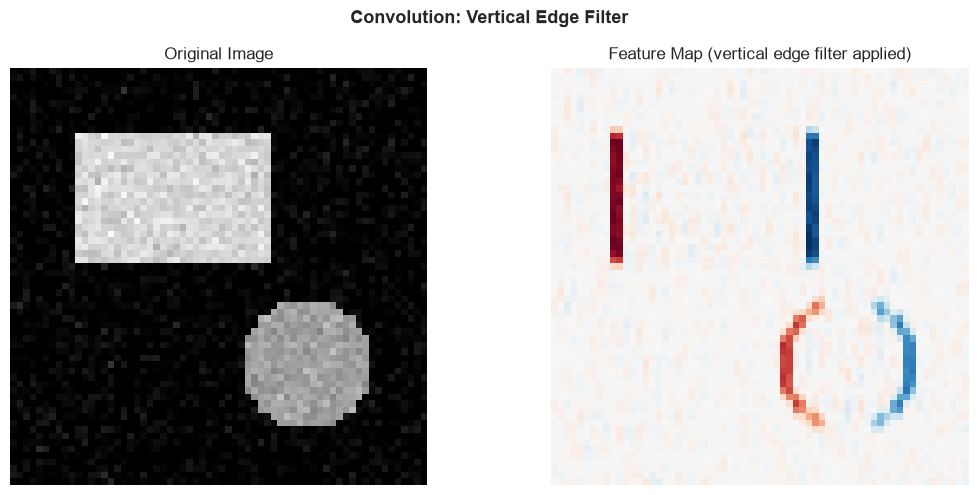

Filter shape  : (3, 3)  →  9 weights
Feature map   : (64, 64)

Filter weights:
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]


In [29]:
# Build a synthetic grayscale image
np.random.seed(42)
img = np.zeros((64, 64), dtype=float)

# Rectangle — clean horizontal and vertical edges
img[10:30, 10:40] = 0.8

# Circular blob
for i in range(64):
    for j in range(64):
        if (i - 45) ** 2 + (j - 45) ** 2 < 100:
            img[i, j] = 0.6

# Add slight noise
img += np.random.normal(0, 0.05, img.shape)
img = np.clip(img, 0, 1)

# Define a vertical edge-detection filter (Sobel-X)
vertical_filter = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
], dtype=float)

# Apply convolution
feature_map = convolve(img, vertical_filter)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("Convolution: Vertical Edge Filter", fontsize=13, fontweight="bold")

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(feature_map, cmap="RdBu")
axes[1].set_title("Feature Map (vertical edge filter applied)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print(f"Filter shape  : {vertical_filter.shape}  →  {vertical_filter.size} weights")
print(f"Feature map   : {feature_map.shape}")
print(f"\nFilter weights:\n{vertical_filter}")

### What the Feature Map Shows

The feature map highlights the left and right boundaries of both shapes —
exactly where pixel intensity changes sharply from dark to light or light to dark.

- **Red values:** dark-to-light transition (left edge of each shape)
- **Blue values:** light-to-dark transition (right edge of each shape)
- **Neutral (beige):** flat regions with no left-to-right intensity change

The top and bottom edges of the rectangle produced no response because they
are horizontal boundaries — this filter only responds to vertical transitions.
The flat interior of each shape also produced no response.

The filter detected the same type of boundary in two different locations —
the rectangle and the circular blob — without any modification. This is
translation invariance: one set of 9 weights, applied everywhere, finds the
same pattern wherever it appears in the image.

---

### Step 4: Why Parameter Sharing Matters

In [30]:
# Dense vs convolution — parameter count comparison
print("Dense Layer vs Convolution — parameter count\n")

scenarios = [
    ("64 × 64 grayscale",   64,  64, 1),
    ("128 × 128 grayscale", 128, 128, 1),
    ("200 × 200 color",     200, 200, 3),
    ("224 × 224 color",     224, 224, 3),
]

filter_weights = 3 * 3

rows = []
for name, h, w, c in scenarios:
    pixels        = h * w * c
    dense_weights = pixels
    saving        = dense_weights // filter_weights
    rows.append({
        "Image size"          : name,
        "Total pixels"        : f"{pixels:,}",
        "Dense weights*"      : f"{dense_weights:,}",
        "Conv filter weights" : filter_weights,
        "Saving factor"       : f"{saving:,}×"
    })

df = pd.DataFrame(rows)
display(df)

print()
print("* Dense weights = connections from all pixels to ONE output neuron.")
print(f"  A first dense layer with 256 neurons multiplies this by 256.")
print(f"\nOne conv filter always uses {filter_weights} weights,",
      "reused across the entire image.")

Dense Layer vs Convolution — parameter count



,Image size,Total pixels,Dense weights*,Conv filter weights,Saving factor
0,64 × 64 grayscale,"4,096","4,096",9,455×
1,128 × 128 grayscale,"16,384","16,384",9,"1,820×"
2,200 × 200 color,"120,000","120,000",9,"13,333×"
3,224 × 224 color,"150,528","150,528",9,"16,725×"



* Dense weights = connections from all pixels to ONE output neuron.
  A first dense layer with 256 neurons multiplies this by 256.

One conv filter always uses 9 weights, reused across the entire image.


### What This Means

A 3×3 convolution filter uses 9 weights across the entire image, no matter
its size. A dense layer needs a separate weight for every pixel-to-neuron
connection — for a 224×224 color image and just one output neuron, that is
already 150,528 weights. Scale to a realistic first layer with 256 neurons
and the count reaches over 38 million — in a single layer.

Convolution is efficient because it assumes that the same pattern can appear
anywhere, and therefore the same filter applies everywhere. Dense layers make
no such assumption — they learn which values appear at which specific positions,
which does not generalize to images and requires far more parameters.

This is why CNNs are the standard choice for image tasks, and why a Dense
Network remains the right choice for the cardiovascular tabular data —
where there is no spatial structure for a filter to exploit.

---

## Summary

| Step | What I did | Result |
|------|-----------|--------|
| 1 | Initialized Sprint 2 experiment log | Sprint 1 references recorded — new baseline TBD on 70K data |
| 2 | Confirmed architecture decision | Dense Network for cardiovascular — CNN for melanoma — RNN TBD |
| 3 | Applied vertical edge filter + visualized feature map | Filter highlighted vertical boundaries regardless of position |
| 4 | Compared Dense vs Conv parameter counts | Conv uses 9 weights — dense needs 150,528+ per neuron |

**Tomorrow — Day 2:** Building a full CNN on the Melanoma dataset —
pooling layers, data augmentation, and transfer learning with a pretrained model.